# Caso 5 — Comparação entre Modelo Vetorial e BM25

Usamos os resultados persistidos no Caso 4 (mesmos rankings, mesmas
métricas) para comparar os dois modelos de forma agregada e, principalmente,
**por consulta**. O objetivo deste caso não é apenas dizer qual modelo tem
a média maior, mas entender *onde* e *por que* eles divergem.


In [1]:
from pathlib import Path
import sys
project_root = Path.cwd()
if not (project_root / "src").is_dir() and (project_root.parent / "src").is_dir():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from src.cranfield_data import load_cranfield
from src.pre_processing import load_preprocessed

df_docs, df_queries, df_qrels = load_cranfield()
preprocessed = load_preprocessed(project_root / "data" / "processed" / "preprocessed_cranfield.pkl")
doc_tokens = preprocessed["stopwords_stemming"]["docs"]
query_tokens_list = preprocessed["stopwords_stemming"]["queries"]
doc_ids = df_docs["doc_id"].tolist()
query_ids = df_queries["query_id"].tolist()
doc_title = dict(zip(df_docs.doc_id, df_docs.title.str.replace("\n", " ")))
query_text = dict(zip(df_queries.query_id, df_queries.text.str.replace("\n", " ")))

RESULTS_DIR = project_root / "data" / "processed"
vsm_eval = pd.read_csv(RESULTS_DIR / "vsm_perquery.csv", dtype={"query_id": str}).set_index("query_id")
bm25_eval = pd.read_csv(RESULTS_DIR / "bm25_perquery.csv", dtype={"query_id": str}).set_index("query_id")
with open(RESULTS_DIR / "vsm_rankings.pkl", "rb") as f:
    vsm_rankings = pickle.load(f)
with open(RESULTS_DIR / "bm25_rankings.pkl", "rb") as f:
    bm25_rankings = pickle.load(f)

## Comparação agregada

O resultado agregado é misto, não uma vitória uniforme de um modelo. O
BM25 tem MAP, NDCG@10 e MRR maiores (MAP 0,3106 contra 0,3015, NDCG@10
0,3557 contra 0,3497 e MRR 0,5455 contra 0,5284). Já o Modelo Vetorial
tem Precision@10, Recall@10 e F1@10 maiores (P@10 0,2418 contra 0,2342 e
Recall@10 0,3987 contra 0,3921). Ou seja, o BM25 tende a ordenar melhor
os documentos relevantes que aparecem, em métricas sensíveis à posição
como MAP, MRR e NDCG, enquanto o Modelo Vetorial recupera, em média, uma
fração ligeiramente maior de documentos relevantes dentro do Top 10, em
métricas de conjunto como Precision@10 e Recall@10. Em qualquer direção,
as diferenças agregadas são pequenas, abaixo de 5% relativos na maioria
das métricas.

In [2]:
agg = pd.DataFrame({
    "Modelo Vetorial": vsm_eval.drop(columns="n_relevant").mean(),
    "BM25": bm25_eval.drop(columns="n_relevant").mean(),
})
agg["BM25 - Vetorial"] = agg["BM25"] - agg["Modelo Vetorial"]
display(agg.round(4))

n_wins_bm25 = (bm25_eval["AP"] > vsm_eval["AP"]).sum()
n_wins_vsm = (vsm_eval["AP"] > bm25_eval["AP"]).sum()
n_ties = (bm25_eval["AP"] == vsm_eval["AP"]).sum()
print(f"\nPor consulta (AP): BM25 melhor em {n_wins_bm25}, Modelo Vetorial melhor em {n_wins_vsm}, "
      f"empate em {n_ties} (de {len(vsm_eval)} consultas)")

,Modelo Vetorial,BM25,BM25 - Vetorial
precision@10,0.2418,0.2342,-0.0076
recall@10,0.3987,0.3921,-0.0066
AP,0.3015,0.3106,0.0091
F1@10,0.2712,0.2650,-0.0062
MRR,0.5284,0.5455,0.0170
ndcg@10,0.3497,0.3557,0.0060



Por consulta (AP): BM25 melhor em 118, Modelo Vetorial melhor em 98, empate em 9 (de 225 consultas)


## Divergência por consulta

A média agregada esconde uma heterogeneidade grande. Olhando consulta a
consulta, o BM25 tem AP maior em 118 das 225 consultas, o Modelo Vetorial
vence em 98 e há 9 empates. Isso indica que a pequena vantagem agregada
do BM25 em MAP não vem de vencer quase sempre por pouco, mas de vencer
com folga em parte das consultas, enquanto perde, também com folga, em
outra parte de tamanho comparável.

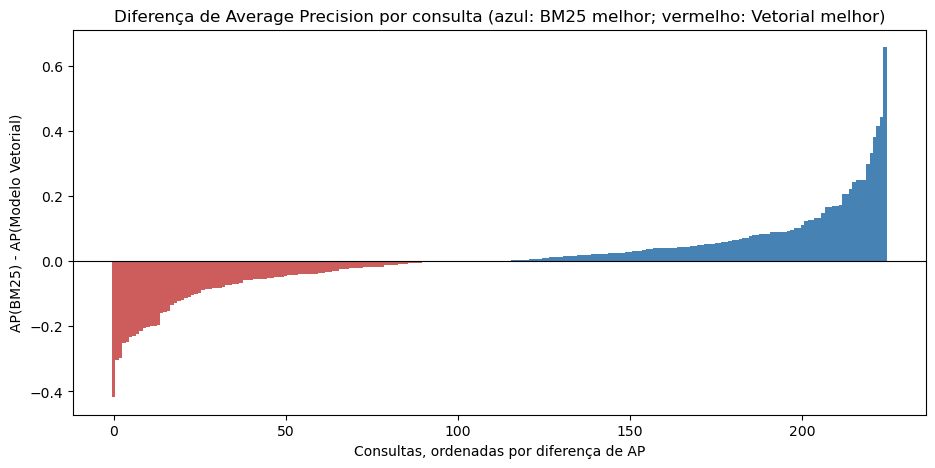

In [3]:
diff = (bm25_eval["AP"] - vsm_eval["AP"]).sort_values()
plt.figure(figsize=(11, 5))
colors = ["indianred" if v < 0 else "steelblue" for v in diff.values]
plt.bar(range(len(diff)), diff.values, color=colors, width=1.0)
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Consultas, ordenadas por diferença de AP")
plt.ylabel("AP(BM25) - AP(Modelo Vetorial)")
plt.title("Diferença de Average Precision por consulta (azul: BM25 melhor; vermelho: Vetorial melhor)")

# Salva a figura em report/figures/ para uso no relatorio. Gerar a figura aqui,
# e nao a mao, garante que ela nunca fique dessincronizada dos resultados.
FIG_DIR = project_root / "report" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIG_DIR / "fig1_diferenca_ap_por_consulta.png", dpi=200, bbox_inches="tight")
plt.show()

## Consultas com maiores diferenças

In [4]:
print("Consultas onde BM25 mais supera o Modelo Vetorial (maior diferença de AP):")
top_bm25 = diff.sort_values(ascending=False).head(5)
display(pd.DataFrame({
    "query": [query_text[q] for q in top_bm25.index],
    "AP_BM25": bm25_eval.loc[top_bm25.index, "AP"].round(3),
    "AP_Vetorial": vsm_eval.loc[top_bm25.index, "AP"].round(3),
    "diferenca": top_bm25.round(3),
}))

print("\nConsultas onde o Modelo Vetorial mais supera o BM25 (maior diferença negativa de AP):")
top_vsm = diff.sort_values().head(5)
display(pd.DataFrame({
    "query": [query_text[q] for q in top_vsm.index],
    "AP_BM25": bm25_eval.loc[top_vsm.index, "AP"].round(3),
    "AP_Vetorial": vsm_eval.loc[top_vsm.index, "AP"].round(3),
    "diferenca": top_vsm.round(3),
}))

Consultas onde BM25 mais supera o Modelo Vetorial (maior diferença de AP):


,query,AP_BM25,AP_Vetorial,diferenca
query_id,,,,
167,exact solution methods for calculating the abl...,0.750,0.091,0.659
36,has anyone investigated relaxation effects on ...,0.502,0.058,0.445
173,references on lyapunov's method on the stabili...,1.000,0.583,0.417
81,what are wind-tunnel corrections for a two-dim...,0.750,0.367,0.383
205,has anyone investigated theoretically whether ...,0.833,0.500,0.333



Consultas onde o Modelo Vetorial mais supera o BM25 (maior diferença negativa de AP):


,query,AP_BM25,AP_Vetorial,diferenca
query_id,,,,
17,can the three-dimensional problem of a transve...,0.090,0.508,-0.418
145,what are the best experimental data and classi...,0.279,0.583,-0.303
77,how close is the comparison of the shock layer...,0.259,0.555,-0.296
95,what is the theoretical heat transfer distribu...,0.450,0.700,-0.250
88,how does a satellite orbit contract under the ...,0.650,0.897,-0.247


### Por que o BM25 vence com folga na consulta 167?

A consulta pede métodos exatos para calcular a perda de massa por ablação
em voo hipersônico. O Modelo Vetorial coloca em primeiro lugar o documento
553, não julgado, que repete o termo `ablat` 8 vezes em 105 tokens mas toca
apenas 6 dos 14 termos da consulta. Todo o seu Top 5 tem esse mesmo perfil,
documentos não julgados saturados em `ablat`, como o 1099 (48 tokens,
`ablat` 5 vezes) e o 1097 (`ablat` 8 vezes, `materi` 7 vezes). O resultado
é um AP de 0,091.

O BM25 prefere o documento 274, relevante de grau 2, que repete `ablat` só
2 vezes mas cobre 9 termos distintos da consulta (`ablat`, `method`,
`materi`, `exact`, `solut`, `mass`, `temperatur`, `loss`, `calcul`), e traz
o segundo relevante, o documento 82 de grau 3, para a 4ª posição. AP de
0,750.

Isso ilustra o papel da saturação de frequência de termo do BM25. A fração
`f*(k1+1)/(f+k1*norm)` cresce rápido nas primeiras ocorrências e se achata
nas seguintes: para o documento 553, com k1=1,2 e b=0,75, ir de 1 para 8
ocorrências de `ablat` multiplica a contribuição do termo por apenas
**1,95**, não por 8.

O Modelo Vetorial não tem esse freio. O `TfidfVectorizer` está com
`sublinear_tf=False`, ou seja, usa a **contagem bruta** de tf, de modo que
as 8 ocorrências entram no vetor com peso integral, 8 vezes o peso de uma
única ocorrência. Combinado com a normalização L2 de um documento curto,
onde poucos termos competem pela mesma norma, isso deixa a repetição de um
único termo raro dominar a direção do vetor do documento 553 e inflar seu
cosseno com a consulta.

In [5]:
# Estudo de caso: consulta 167 (BM25 >> Modelo Vetorial)
q = "167"
print(f"Consulta {q}: {query_text[q]}")
print(f"Tokens: {query_tokens_list[query_ids.index(q)]}\n")

grades = dict(zip(df_qrels[df_qrels.query_id == q].doc_id, df_qrels[df_qrels.query_id == q].relevance))
for did in ["553", "274"]:
    idx = doc_ids.index(did)
    toks = doc_tokens[idx]
    from collections import Counter
    counts = Counter(toks)
    q_toks = set(query_tokens_list[query_ids.index(q)])
    overlap = {t: counts[t] for t in q_toks if counts[t] > 0}
    print(f"doc {did} (grau={grades.get(did, 'não julgado')}, {len(toks)} tokens): "
          f"sobreposição com a consulta = {overlap}")

Consulta 167: exact solution methods for calculating the ablative mass loss of a material ablating at high temperatures in a hypersonic flight environment .
Tokens: ['exact', 'solut', 'method', 'calcul', 'abl', 'mass', 'loss', 'materi', 'ablat', 'high', 'temperatur', 'hyperson', 'flight', 'environ']

doc 553 (grau=não julgado, 105 tokens): sobreposição com a consulta = {'flight': 1, 'solut': 3, 'materi': 5, 'mass': 1, 'hyperson': 1, 'ablat': 8}
doc 274 (grau=2, 142 tokens): sobreposição com a consulta = {'temperatur': 2, 'exact': 1, 'solut': 2, 'method': 2, 'loss': 1, 'materi': 1, 'mass': 3, 'calcul': 1, 'ablat': 2}


### Por que o Modelo Vetorial vence com folga na consulta 17?

Aqui o padrão se inverte. A consulta pergunta se o problema tridimensional
de um escoamento potencial transversal sobre um corpo de revolução pode ser
reduzido a um problema bidimensional. Seus termos definidores são
`transvers` e `potenti`; os demais (`problem`, `flow`, `bodi`, `dimension`,
`three`, `two`, `reduc`) são genéricos e frequentes na coleção.

O BM25 coloca em 1º o documento 1108, não julgado, com 154 tokens, que
acumula ocorrências exatamente dos termos genéricos (`problem` 6 vezes,
`flow` 6, `bodi` 5, `reduc` 3) e **não contém nem `potenti` nem
`transvers`**. Em 2º vem o 1281, também não julgado, com `dimension` 10
vezes e `three` 7 vezes. Nenhum relevante entra no Top 5, e o AP fica em
0,090.

O Modelo Vetorial acerta em 1º o documento 106, relevante de grau 2, com
apenas 43 tokens e título "the transverse potential flow past a body of
revolution": ele casa `potenti` 3 vezes, `transvers` 2, `revolut` 3 e
`bodi` 4, isto é, justamente os termos específicos, e ignora os genéricos.
AP de 0,508.

O mecanismo é o oposto do da consulta 167. O BM25 soma contribuições ao
longo de todos os termos da consulta, inclusive os de idf baixo, desde que
apareçam com frequência razoável, o que permite que um documento longo,
cobrindo superficialmente muitos termos comuns, acumule score competitivo
mesmo sem tocar nos termos que definem a pergunta. Já o cosseno depende da
**direção** do vetor: um documento curto, dominado por poucos termos de
alto idf que coincidem com a consulta, fica quase paralelo a ela.

In [6]:
# Estudo de caso: consulta 17 (Modelo Vetorial >> BM25)
q = "17"
print(f"Consulta {q}: {query_text[q]}")
print(f"Tokens: {query_tokens_list[query_ids.index(q)]}\n")

grades = dict(zip(df_qrels[df_qrels.query_id == q].doc_id, df_qrels[df_qrels.query_id == q].relevance))
for did in ["1108", "106"]:
    idx = doc_ids.index(did)
    toks = doc_tokens[idx]
    from collections import Counter
    counts = Counter(toks)
    q_toks = set(query_tokens_list[query_ids.index(q)])
    overlap = {t: counts[t] for t in q_toks if counts[t] > 0}
    print(f"doc {did} (grau={grades.get(did, 'não julgado')}, {len(toks)} tokens): "
          f"sobreposição com a consulta = {overlap}")

# Trava os fatos citados na analise acima: se um reprocessamento futuro mudar
# estes rankings, a celula quebra em vez de deixar o texto mentir em silencio.
assert bm25_rankings["17"][0] == "1108", bm25_rankings["17"][:5]
assert vsm_rankings["17"][0] == "106", vsm_rankings["17"][:5]
assert bm25_rankings["167"][0] == "274" and bm25_rankings["167"][3] == "82", bm25_rankings["167"][:5]
assert vsm_rankings["167"][0] == "553", vsm_rankings["167"][:5]
print("OK: os documentos citados na analise seguem nas posicoes descritas.")

Consulta 17: can the three-dimensional problem of a transverse potential flow about a body of revolution be reduced to a two-dimensional problem .
Tokens: ['three', 'dimension', 'problem', 'transvers', 'potenti', 'flow', 'bodi', 'revolut', 'reduc', 'two', 'dimension', 'problem']

doc 1108 (grau=não julgado, 154 tokens): sobreposição com a consulta = {'three': 2, 'dimension': 2, 'problem': 6, 'reduc': 3, 'flow': 6, 'bodi': 5, 'revolut': 2}
doc 106 (grau=2, 43 tokens): sobreposição com a consulta = {'transvers': 2, 'flow': 3, 'potenti': 3, 'bodi': 4, 'revolut': 3}
OK: os documentos citados na analise seguem nas posicoes descritas.


### Síntese

As duas consultas de estudo de caso mostram que a diferença entre os
modelos não é aleatória. Ela nasce de dois mecanismos conhecidos e
opostos.

1. **Saturação de frequência no BM25.** Penaliza documentos que inflam sua
   relevância aparente repetindo excessivamente um único termo e favorece
   a cobertura de múltiplos aspectos da consulta. Ajuda o BM25 quando o
   documento relevante é mais completo e o distrator é repetitivo, como na
   consulta 167.
2. **Concentração vetorial no Modelo Vetorial.** Favorece documentos curtos
   e muito focados em poucos termos raros compartilhados com a consulta,
   mesmo quando não cobrem os termos genéricos dela. Ajuda o Vetorial
   quando o documento relevante é curto e específico e o distrator do BM25
   é longo e genérico, como na consulta 17.

Os dois mecanismos são a mesma moeda vista de lados opostos: um premia
**cobertura**, o outro premia **especificidade**. Nenhum é certo ou errado
em geral, o que explica por que a diferença agregada entre os modelos é
pequena apesar de, consulta a consulta, as diferenças individuais serem
grandes e sistemáticas.